In [233]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from music21 import *

In [335]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import preprocessing_utils as pp
from Importables import pitchanalysis_utils as pa
from Importables import intervalanalysis_utils as ia

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [126]:
dissonance_table = {
    0: 0.0,    # Unison
    1: 1.0,    # m2/M7
    2: 0.6,    # M2/m7
    3: 0.4,    # m3/M6
    4: 0.2,    # M3/m6 
    5: 0.0,    # P4/P5
    6: 0.8,    # Tritone
}

pitch_class_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 
                     'F#', 'G', 'G#', 'A', 'A#', 'B']

In [263]:
path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/metadata.tsv"
metadata = pd.read_csv(path, sep='\t')
metadata

,rel_paths,fnames,last_mc,last_mn,KeySig,TimeSig,label_count,annotated_key,composer,workTitle,...,staff_7_ambitus,staff_7_instrument,staff_8_ambitus,staff_8_instrument,staff_9_ambitus,staff_9_instrument,transcribed_instruments,transcribed_sections,transposition,year_certain
0,by_Alexander_Booker,Snarky_Puppy-Shapons_Vindaloo,142,142,"1: 0, 113: -3, 134: 0","1: 9/8, 2: 7/8, 4: 9/8, 5: 7/8, 7: 9/8, 8: 7/8...",8,NaN,Väsen,Shapons Vindaloo,...,NaN,NaN,NaN,NaN,NaN,NaN,"ac-g, e-g, b, nyckelharpa",complete,Concert Key,1
1,by_Alexander_Booker,The_Fearless_Flyers-Ace_of_Aces,57,57,1: 3,1: 4/4,2,NaN,Smith/Dart/Wong/Lettieri/Stratton,Ace Of Aces,...,NaN,NaN,NaN,NaN,NaN,NaN,"g, b, dr",complete,Concert Key,1
2,by_Alexander_Booker,Vulfpeck-Fugue_State,71,71,1: 0,1: 4/4,13,NaN,"Woody Goss, Jack Stratton",Fugue State,...,NaN,NaN,NaN,NaN,NaN,NaN,"ep, g, b, dr",complete,Concert Key,1
3,by_Carles_Margarit,12 Keys Blues - Bob Mintzer,156,156,1: 0,1: 4/4,169,NaN,NaN,12 Keys Blues,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,solo,Bb,1
4,by_Carles_Margarit,26_2 - Coltrane (Concert Key),298,297,1: -1,"1: 4/4, 296: 2/4, 298: 4/4",347,NaN,John Coltrane,26-2,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,complete,Concert Key,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,by_seemajorsheetmusic,Superstition - Stevie Wonder,89,89,1: -3,1: 4/4,402,NaN,Comp.: Stevie Wonder,Superstition,...,30-46 (Gb1-Bb2),Bass Guitar (2),51-70 (Eb3-Bb4),NaN,NaN,NaN,"as, ts, tp, tb, g, b, key",complete,"as in Eb, ts, tp in Bb, tb, g, b, key in Conce...",1
289,by_seemajorsheetmusic,The Survivor - Jan Garbarek,27,27,1: 0,1: 4/4,43,NaN,Comp.: Jan Garbarek,The Survivor,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,melody,Bb,1
290,by_seemajorsheetmusic,The Vow - Ole børud,105,105,"1: -1, 49: 6",1: 4/4,160,NaN,Ole Børud,The Vow,...,28-55 (E1-G3),Bass Guitar (2),62-79 (D4-G5),NaN,NaN,NaN,"as, ts, tp, tb, dr, g, b, el-org",complete,"as in Eb, ts, tp in Bb, tb, g, b, org in Conce...",0
291,by_seemajorsheetmusic,The World is Getting Smaller - Snarky Puppy,221,221,1: 1,1: 4/4,392,NaN,Comp.: Michael League\nTranscribed & Arranged ...,The World Is Getting Smaller,...,28-60 (E1-C4),Bass Guitar (2),70-71 (Bb4-B4),Keyboard,NaN,NaN,"ss, ts, tp, tb, b, g, key, dr",complete without solos,"ss, ts, tp in Bb, tb, g, b, key in Concert Key",1


## Spelled pitch and interval class inference

In [372]:
path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/by_William_Hughes_(only_Bill_Evans)/Everything Happens To Me.xml"
score = m21.converter.parse(path)
key = score.analyze('key')
print(key.tonic.name, key.mode)

B- major


In [409]:
import music21 as m21

# Takes df (notes of a single composition) and returns df (contains order, spelled_pitch based of key)
def preprocess_df(fname):
    base_path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions"
    notes_path = base_path + "/notes/" + fname + ".tsv"

    try:
        info = metadata[metadata['fnames'] == fname]
        if info.empty:
            raise ValueError(f"fname '{fname}' not found in metadata!")
        
        comp = pd.read_csv(notes_path, sep='\t')

        # Attach metadata as attrs:
        comp.attrs['artists'] = info['artists'].iloc[0]
        comp.attrs['title'] = info['workTitle'].iloc[0]
        comp.attrs['recording_year'] = info['recording_year'].iloc[0]
        comp.attrs['rel_paths'] = info['rel_paths'].iloc[0]
        comp.attrs['fnames'] = info['fnames'].iloc[0]

        # Preprocessing:
        comp['pc'] = comp['midi'] % 12
        comp = comp[comp['pc'].notna()]
        comp['pc'] = comp['pc'].astype(int)
        comp['note'] = comp['pc'].map(lambda x: pitch_class_names[x])

        comp['mc_onset_float'] = comp['mc_onset'].apply(lambda x: float(Fraction(x)))
        comp['order'] = comp['mc'] + comp['mc_onset_float']

        # Attempt to determine key:
        xml_path = base_path + '/' + comp.attrs['rel_paths'] + '/' + comp.attrs['fnames'] + '.xml'

        try:
            key = determine_key(xml_path)
            comp.attrs['key'] = key
            comp['spelled_pitch'] = comp['midi'].apply(lambda x: spelled_pitch(x, key))
        
        except Exception as e:
            print(f"XML file not found or error in determine_key: {e}")
            comp.attrs['key'] = None

    except Exception as e:
        print(f"Error processing fname '{fname}': {e}")
        return None  # Return None if failed

    return comp

    
# Takes notes df of a composition and returns key object
def determine_key(composition_path):
    score = m21.converter.parse(composition_path)
    key = score.analyze('key')
    return key

# takes midi_value (int) and key (string) and returns spelled-pitch (string)
def spelled_pitch(midi_value, key):
    if not isinstance(key, m21.key.Key):
        key = m21.key.Key(key)
        
    n = m21.note.Note()
    n.pitch.midi = midi_value

    scale = key.getScale()
    spelled = scale.getRealizationForPitch(n.pitch)[0]

    return spelled.name


# Takes list of notes and returns list of interval classes between all note pairs
def interval_class(notes):
    interval_classes = []
    
    # Generate all unique pairs:
    pairs = itertools.combinations(notes, 2)
    
    for n1_str, n2_str in pairs:
        # Convert to music21 Notes:
        n1 = m21.note.Note(n1_str)
        n2 = m21.note.Note(n2_str)
        
        # Compute interval:
        i = m21.interval.Interval(noteStart=n1, noteEnd=n2)
        
        # Append the interval class:
        interval_classes.append(i.intervalClass)
    
    return interval_classes


In [411]:
fname = 'Four - Miles Davis (Concert Key)'
df = preprocess_df(fname)
df

XML file not found or error in determine_key: 'MajorScale' object has no attribute 'getRealizationForPitch'


,mc,mn,mc_onset,mn_onset,timesig,staff,voice,duration,gracenote,nominal_duration,scalar,tied,tpc,midi,volta,chord_id,pc,note,mc_onset_float,order
0,9,9,5/8,5/8,4/4,1,1,1/8,NaN,1/8,1,NaN,0,72,NaN,0,0,C,0.625,9.625
1,9,9,3/4,3/4,4/4,1,1,1/8,NaN,1/8,1,NaN,2,74,NaN,1,2,D,0.750,9.750
2,9,9,7/8,7/8,4/4,1,1,1/8,NaN,1/8,1,NaN,4,76,NaN,2,4,E,0.875,9.875
3,10,10,1/8,1/8,4/4,1,1,1/8,NaN,1/8,1,NaN,0,72,NaN,3,0,C,0.125,10.125
4,10,10,1/4,1/4,4/4,1,1,1/8,NaN,1/8,1,NaN,2,74,NaN,4,2,D,0.250,10.250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
803,369,369,7/8,7/8,4/4,1,1,1/8,NaN,1/8,1,1.0,-4,80,NaN,794,8,G#,0.875,369.875
804,370,370,0,0,4/4,2,1,1,NaN,1,1,-1.0,4,76,NaN,799,4,E,0.000,370.000
805,370,370,0,0,4/4,1,1,1/8,NaN,1/8,1,-1.0,-4,80,NaN,796,8,G#,0.000,370.000
806,370,370,1/8,1/8,4/4,1,1,1/8,NaN,1/8,1,NaN,-1,77,NaN,797,5,F,0.125,370.125


## Exploratory interval analysis

#### Should we separate them into major and minor key compositions??

In [ ]:
# Takes list of pc and returns int (normalized dissonance index of pitch class set)
def dissonance(harmony):
    ic = interval_class(harmony)
    num_notes = len(harmony)
    dissonance = (sum([dissonance_table[i] for i in ic])) / num_notes
    return dissonance 

In [345]:
dfs = []
for row in range(metadata.shape[0]):
    base_path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/notes" 
    path_row = base_path + "/" + metadata.iloc[row,1] + ".tsv"
    try: 
        df_raw = pd.read_csv(path_row, sep='\t')
        df = pp.preprocess_df(df_raw)
        pcs_df = pp.generate_pcs(df)

        if (contains_harmony(pcs_df) == True):
            pcs_df['dissonance'] = pcs_df['pcs'].apply(dissonance)
            mean = pcs_df['dissonance'].mean()
            dfs.append({
                'artists': metadata.iloc[row]['artists'],
                'workTitle': metadata.iloc[row]['workTitle'],
                'fnames': metadata.iloc[row]['fnames'],
                'recording_year': metadata.iloc[row]['recording_year'],
                'mean_dissonance': mean
            })
    except Exception as e:
        continue

dfs = pd.DataFrame(dfs)


In [346]:
dfs

,artists,workTitle,fnames,recording_year,mean_dissonance
0,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015,0.140445
1,The Fearless Flyers,Ace Of Aces,The_Fearless_Flyers-Ace_of_Aces,2018,0.178088
2,Vulfpeck,Fugue State,Vulfpeck-Fugue_State,2014,0.347873
3,Bob Mintzer,12 Keys Blues,12 Keys Blues - Bob Mintzer,2010,0.002090
4,John Coltrane,26-2,26_2 - Coltrane (Concert Key),1964,0.002936
...,...,...,...,...,...
198,Pat Metheny,Outcasts,Pat_Metheny-Outcasts,1999,0.536690
199,Paul Desmond,All The Things You Are,All The Things You Are - Paul Desmond,1962,0.006656
200,Earth Wind and Fire,Can't Hide Love,"Can't Hide Love - Earth, Wind & Fire",1975,0.552578
201,Stevie Wonder,I Wish,I Wish - Stevie Wonder,1976,0.304098


In [271]:
dfs_bytime= dfs.copy()
dfs_bytime['recording_year'] = pd.to_numeric(dfs_bytime['recording_year'], errors='coerce')
dfs_bytime = dfs_bytime[dfs_bytime['recording_year'].notna()].copy()
dfs_bytime['recording_year'] = dfs_bytime['recording_year'].astype('Int64')
dfs_bytime

,artists,workTitle,fnames,recording_year,mean_dissonance
0,Snarky Puppy,Shapons Vindaloo,Snarky_Puppy-Shapons_Vindaloo,2015,0.318946
1,The Fearless Flyers,Ace Of Aces,The_Fearless_Flyers-Ace_of_Aces,2018,0.356176
2,Vulfpeck,Fugue State,Vulfpeck-Fugue_State,2014,0.438846
3,Bob Mintzer,12 Keys Blues,12 Keys Blues - Bob Mintzer,2010,0.500000
4,John Coltrane,26-2,26_2 - Coltrane (Concert Key),1964,0.412500
...,...,...,...,...,...
197,Pat Metheny,Outcasts,Pat_Metheny-Outcasts,1999,0.653362
198,Paul Desmond,All The Things You Are,All The Things You Are - Paul Desmond,1962,0.175000
199,Earth Wind and Fire,Can't Hide Love,"Can't Hide Love - Earth, Wind & Fire",1975,0.714432
200,Stevie Wonder,I Wish,I Wish - Stevie Wonder,1976,0.485320


### Plot Average DI over time

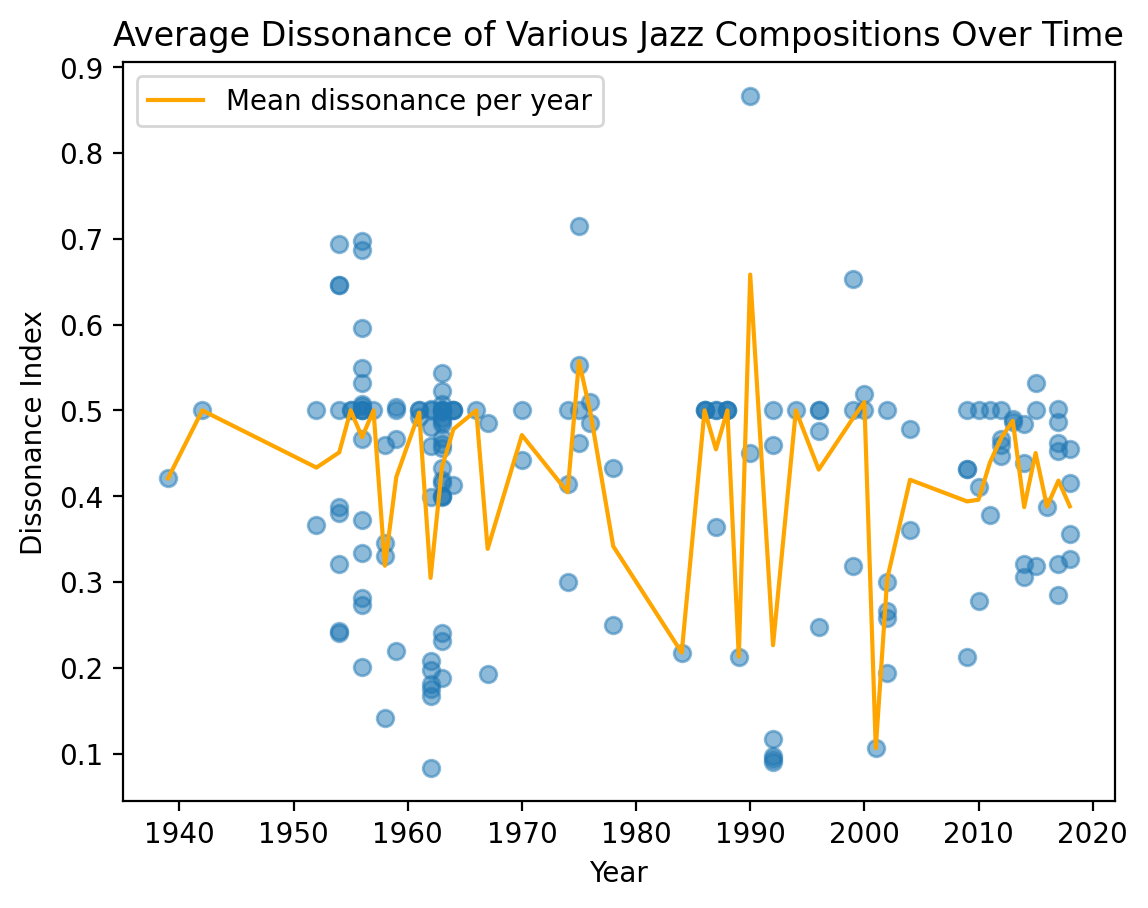

In [274]:
x = dfs_bytime['recording_year']
y = dfs_bytime['mean_dissonance']
means = dfs_bytime.groupby('recording_year', as_index=False).mean(numeric_only=True)
plt.title('Average Dissonance of Various Jazz Compositions Over Time')
plt.xlabel('Year')
plt.ylabel('Dissonance Index')
plt.scatter(x,y,alpha=0.5)
plt.plot(means['recording_year'], means['mean_dissonance'], color='orange', label = 'Mean dissonance per year')
plt.legend()
plt.show()

### Plot DI by artists with more than 5 compositions

In [197]:
def groupby_artist(dfs, length=5):
    artist_grouped = dfs.copy()
    ref = dfs.copy()
    ref = ref.groupby('artists', as_index=False).agg(list).reset_index()
    ref = ref[ref['workTitle'].apply(lambda x: len(x) > length)].copy()
    artist_grouped = artist_grouped[artist_grouped['artists'].isin(ref['artists'])]
    return artist_grouped

In [192]:
artist_grouped = groupby_artist(dfs_bytime, length=5)
artist_grouped.head(5)

,artists,workTitle,fnames,recording_year,mean_dissonance
4,John Coltrane,26-2,26_2 - Coltrane (Concert Key),1964,0.41250
8,Paul Desmond,All The Things You Are,All The Things You Are - Paul Desmond (Concert...,1962,0.18125
14,Paul Desmond,Autumn Leaves,Autumn Leaves - Desmond (Concert Key),1974,0.30000
15,Miles Davis,Bags’ Groove,Bags Groove - Miles Davis (Concert Key),1957,0.50000
16,Paul Desmond,Black Orpheus,Black Orpheus - Paul Desmond (Concert Key),1963,0.24000


In [194]:
artist_year_means = artist_grouped.groupby(['artists', 'recording_year'], as_index=False)['mean_dissonance'].mean()
artist_year_means.head(10)

,artists,recording_year,mean_dissonance
0,Bill Evans,1956,0.500151
1,Bill Evans,1958,0.318959
2,Bill Evans,1962,0.460211
3,Bill Evans,1963,0.466219
4,Dexter Gordon,1956,0.500000
5,Dexter Gordon,1962,0.348837
6,Dexter Gordon,1964,0.500000
7,Dexter Gordon,1967,0.484848
8,Dexter Gordon,1970,0.442424
9,Dexter Gordon,1975,0.504957


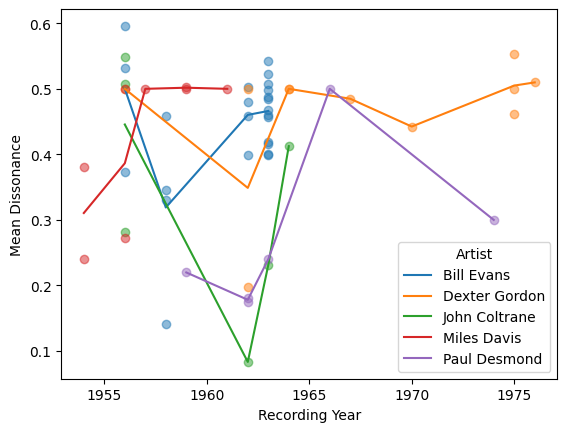

In [188]:
artist_year_means = artist_grouped.groupby(['artists', 'recording_year'], as_index=False)['mean_dissonance'].mean()

fig, ax = plt.subplots()

for artist, group in artist_grouped.groupby('artists'):
    ax.scatter(group['recording_year'], group['mean_dissonance'], alpha=0.5)

for artist, group in artist_year_means.groupby('artists'):
    ax.plot(group['recording_year'], group['mean_dissonance'], label=artist)
    
ax.set_xlabel('Recording Year')
ax.set_ylabel('Mean Dissonance')
ax.legend(title='Artist')
plt.show()


### Group by Standard

In [213]:
def groupby_standard(dfs, length=3):
    title_grouped = dfs.copy()
    ref = dfs.copy()
    ref = ref.groupby('workTitle', as_index=False).agg(list).reset_index()
    ref = ref[ref['recording_year'].apply(lambda x: len(x) > length)].copy()
    title_grouped = title_grouped[title_grouped['workTitle'].isin(ref['workTitle'])]
    return title_grouped, ref

In [219]:
title_grouped, ref = groupby_standard(dfs_bytime, length=3)
title_grouped

,artists,workTitle,fnames,recording_year,mean_dissonance
7,Lennie Niehaus,All The Things You Are,All The Things You Are - Lennie Neihaus (Conce...,1955,0.500000
8,Paul Desmond,All The Things You Are,All The Things You Are - Paul Desmond (Concert...,1962,0.181250
21,Full Transcription,Blues By Five,Blues By Five - Full Transcription,1956,0.686545
22,John Coltrane,Blues By Five,Blues By Five - John Coltrane (Concert Key),1956,0.548889
23,Miles Davis,Blues By Five,Blues By Five - Miles Davis (Concert Key),1956,0.500000
24,Paul Chambers,Blues By Five,Blues By Five - Paul Chambers,1956,0.333333
25,Red Garland,Blues By Five,Blues By Five - Red Garland,1956,0.697272
48,Clifford Brown,Joy Spring,Joy Spring - Brown (Concert Key),1954,0.646377
49,Harold Land,Joy Spring,Joy Spring - Land (Concert Key),1954,0.694545
50,"Harold Land, Clifford Brown",Joy Spring,Joy Spring - Land_Brown (Concert Key),1954,0.646377
